In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Load CSVs
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')


In [6]:
# Quick check
print(matches.shape, deliveries.shape)
print(matches.columns.tolist())
print(deliveries.columns.tolist())

(1095, 20) (260920, 17)
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [8]:
# Load into SQLite
conn = sqlite3.connect('ipl.db')
matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)
print("Database created.")

Database created.


In [10]:
def sql(query):
    return pd.read_sql(query, conn)

In [72]:
# 1. Top 10 run scorers all time
top_batsmen = sql("""
    SELECT batter, SUM(batsman_runs) as total_runs, COUNT(*) as balls_faced,
           ROUND(SUM(batsman_runs)*100.0/COUNT(*), 2) as strike_rate
    FROM deliveries
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 10
""")

top_batsmen


,batter,total_runs,balls_faced,strike_rate
0,V Kohli,8014,6236,128.51
1,S Dhawan,6769,5483,123.45
2,RG Sharma,6630,5183,127.92
3,DA Warner,6567,4849,135.43
4,SK Raina,5536,4177,132.54
5,MS Dhoni,5243,3947,132.84
6,AB de Villiers,5181,3487,148.58
7,CH Gayle,4997,3516,142.12
8,RV Uthappa,4954,3927,126.15
9,KD Karthik,4843,3687,131.35


In [74]:
# 2. Most match wins by team
team_wins = sql("""
    SELECT winner, COUNT(*) as wins
    FROM matches
    WHERE winner IS NOT NULL AND winner != ''
    GROUP BY winner
    ORDER BY wins DESC
""")
team_wins

,winner,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Sunrisers Hyderabad,88
6,Kings XI Punjab,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


In [76]:

# 3. Toss decision impact
toss_impact = sql("""
    SELECT toss_decision,
           COUNT(*) as total_matches,
           SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) as won_match,
           ROUND(SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) as win_pct
    FROM matches
    WHERE winner IS NOT NULL AND winner != ''
    GROUP BY toss_decision
""")
toss_impact

,toss_decision,total_matches,won_match,win_pct
0,bat,390,177,45.38
1,field,700,377,53.86


In [78]:
# 4. Top 10 venues by matches hosted
venue_matches = sql("""
    SELECT venue, COUNT(*) as matches_hosted
    FROM matches
    GROUP BY venue
    ORDER BY matches_hosted DESC
    LIMIT 10
""")
venue_matches

,venue,matches_hosted
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


In [80]:
# 5. Top wicket-takers (bowlers)
top_bowlers = sql("""
    SELECT bowler, COUNT(*) as wickets
    FROM deliveries
    WHERE dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
    AND dismissal_kind IS NOT NULL AND dismissal_kind != ''
    GROUP BY bowler
    ORDER BY wickets DESC
    LIMIT 10
""")
top_bowlers

,bowler,wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,SP Narine,180
5,R Ashwin,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


In [82]:

# 6. Season-wise total runs
season_runs = sql("""
    SELECT m.season, SUM(d.total_runs) as total_runs, COUNT(DISTINCT m.id) as matches
    FROM deliveries d
    JOIN matches m ON d.match_id = m.id
    GROUP BY m.season
    ORDER BY m.season
""")
season_runs

,season,total_runs,matches
0,2007/08,17937,58
1,2009,16353,57
2,2009/10,18883,60
3,2011,21154,73
4,2012,22453,74
5,2013,22602,76
6,2014,18931,60
7,2015,18353,59
8,2016,18862,60
9,2017,18786,59


In [70]:
# 7. Highest individual scores in a single match
top_scores = sql("""
    SELECT match_id, batter, SUM(batsman_runs) as innings_score
    FROM deliveries
    GROUP BY match_id, batter
    ORDER BY innings_score DESC
    LIMIT 10
""")
top_scores

,match_id,batter,innings_score
0,598027,CH Gayle,175
1,335982,BB McCullum,158
2,1304112,Q de Kock,140
3,829795,AB de Villiers,133
4,1216510,KL Rahul,132
5,980987,AB de Villiers,129
6,1370352,Shubman Gill,129
7,548372,CH Gayle,128
8,1136602,RR Pant,128
9,419137,M Vijay,127


In [86]:
# 8. Win by runs vs win by wickets ratio
win_type = sql("""
    SELECT 
        SUM(CASE WHEN result = 'runs' THEN 1 ELSE 0 END) as won_by_runs,
        SUM(CASE WHEN result = 'wickets' THEN 1 ELSE 0 END) as won_by_wickets
    FROM matches
    WHERE result IS NOT NULL AND result != ''
""")
win_type

,won_by_runs,won_by_wickets
0,498,578


In [92]:
# 9. Player of the match awards
potm = sql("""
    SELECT player_of_match, COUNT(*) as awards
    FROM matches
    WHERE player_of_match IS NOT NULL AND player_of_match != ''
    GROUP BY player_of_match
    ORDER BY awards DESC
    LIMIT 10
""")
potm

,player_of_match,awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,V Kohli,18
4,DA Warner,18
5,MS Dhoni,17
6,YK Pathan,16
7,SR Watson,16
8,RA Jadeja,16
9,SP Narine,15


In [100]:
# 10. Super overs count per season
super_overs = sql("""
    SELECT m.season, COUNT(*) as super_overs
    FROM matches m
    WHERE m.super_over != 'N'
    GROUP BY m.season
""")
super_overs

,season,super_overs
0,2009,1
1,2009/10,1
2,2013,2
3,2014,1
4,2015,1
5,2017,1
6,2019,2
7,2020/21,4
8,2021,1


In [102]:
# Print all
for name, df in [('Top Batsmen', top_batsmen), ('Team Wins', team_wins),
                  ('Toss Impact', toss_impact), ('Venues', venue_matches),
                  ('Top Bowlers', top_bowlers), ('Season Runs', season_runs)]:
    print(f"\n--- {name} ---")
    print(df.to_string(index=False))


--- Top Batsmen ---
        batter  total_runs  balls_faced  strike_rate
       V Kohli        8014         6236       128.51
      S Dhawan        6769         5483       123.45
     RG Sharma        6630         5183       127.92
     DA Warner        6567         4849       135.43
      SK Raina        5536         4177       132.54
      MS Dhoni        5243         3947       132.84
AB de Villiers        5181         3487       148.58
      CH Gayle        4997         3516       142.12
    RV Uthappa        4954         3927       126.15
    KD Karthik        4843         3687       131.35

--- Team Wins ---
                     winner  wins
             Mumbai Indians   144
        Chennai Super Kings   138
      Kolkata Knight Riders   131
Royal Challengers Bangalore   116
           Rajasthan Royals   112
        Sunrisers Hyderabad    88
            Kings XI Punjab    88
           Delhi Daredevils    67
             Delhi Capitals    48
            Deccan Chargers    29
   

In [104]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

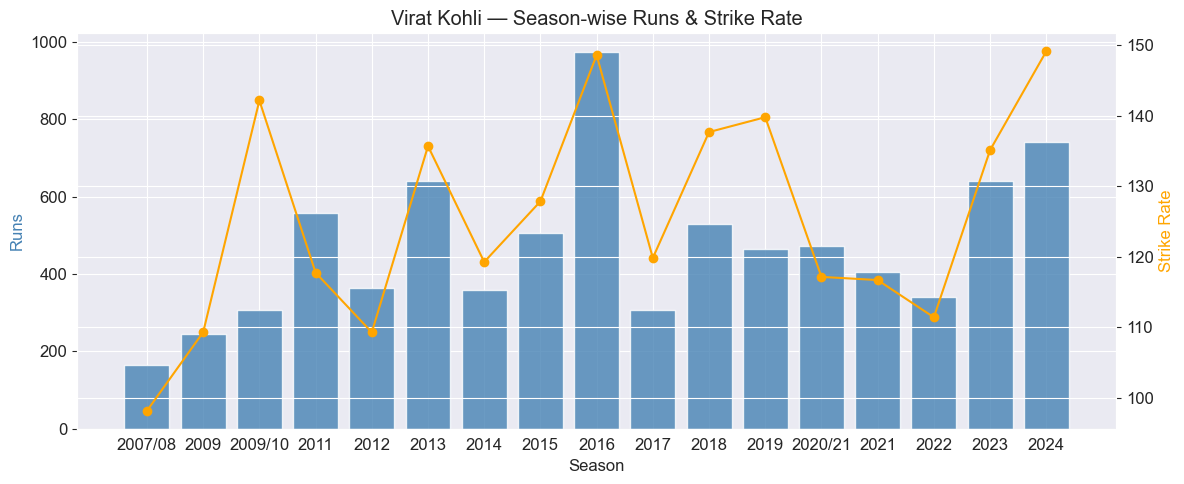

In [108]:
kohli = deliveries[deliveries['batter'] == 'V Kohli'].copy()
kohli = kohli.merge(matches[['id', 'season']], left_on='match_id', right_on='id')

kohli_yearly = kohli.groupby('season').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count')
).reset_index()
kohli_yearly['strike_rate'] = (kohli_yearly['runs'] / kohli_yearly['balls'] * 100).round(2)

fig, ax1 = plt.subplots()
ax1.bar(kohli_yearly['season'], kohli_yearly['runs'], color='steelblue', alpha=0.8, label='Runs')
ax2 = ax1.twinx()
ax2.plot(kohli_yearly['season'], kohli_yearly['strike_rate'], color='orange', marker='o', label='Strike Rate')
ax1.set_xlabel('Season')
ax1.set_ylabel('Runs', color='steelblue')
ax2.set_ylabel('Strike Rate', color='orange')
plt.title("Virat Kohli — Season-wise Runs & Strike Rate")
fig.tight_layout()
plt.savefig('kohli_performance.png', dpi=150)
plt.show()

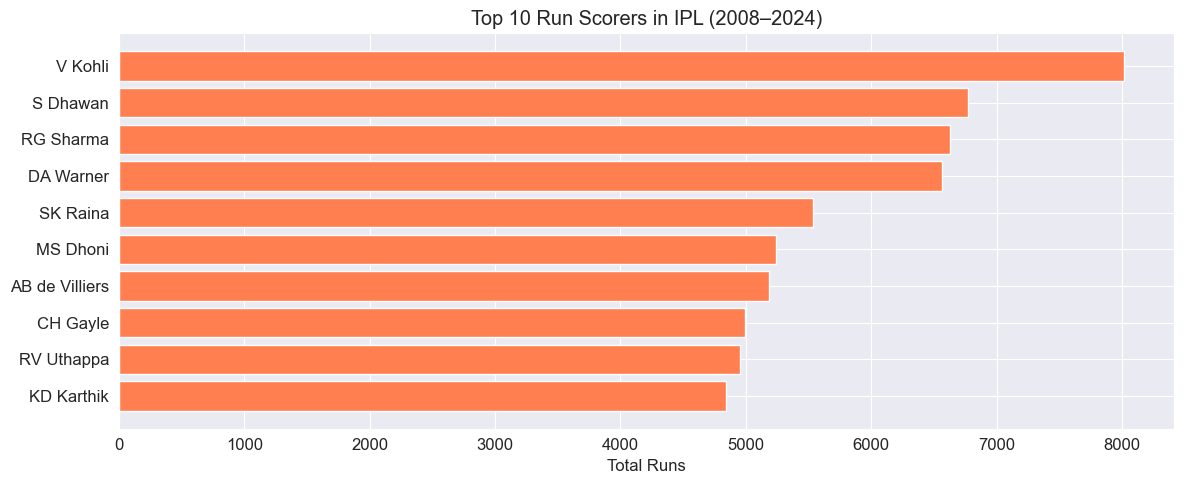

In [114]:
plt.barh(top_batsmen['batter'][::-1], top_batsmen['total_runs'][::-1], color='coral')
plt.xlabel('Total Runs')
plt.title('Top 10 Run Scorers in IPL (2008–2024)')
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150)
plt.show()

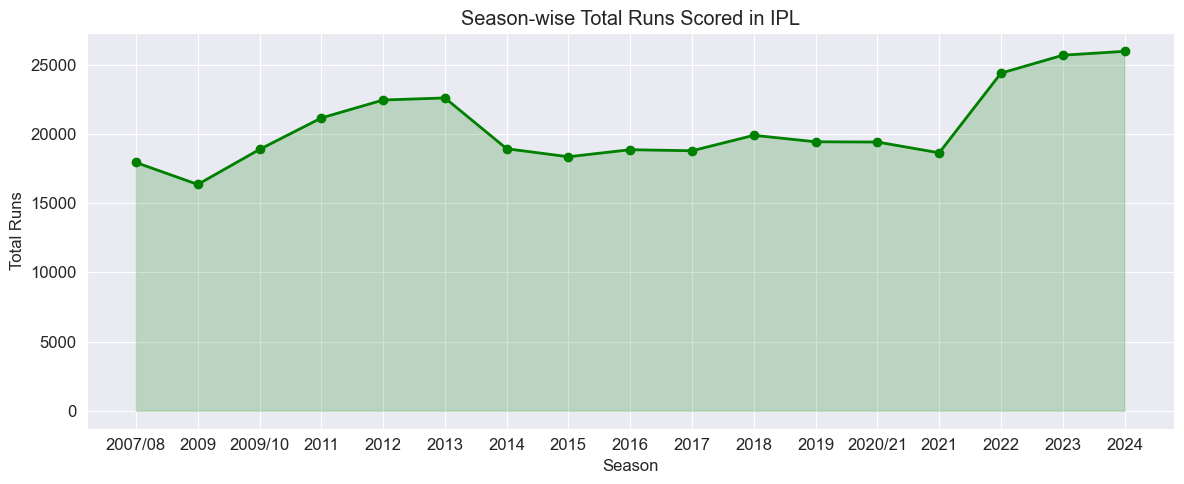

In [116]:
plt.plot(season_runs['season'], season_runs['total_runs'], marker='o', color='green', linewidth=2)
plt.fill_between(season_runs['season'], season_runs['total_runs'], alpha=0.2, color='green')
plt.title('Season-wise Total Runs Scored in IPL')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig('season_runs.png', dpi=150)
plt.show()

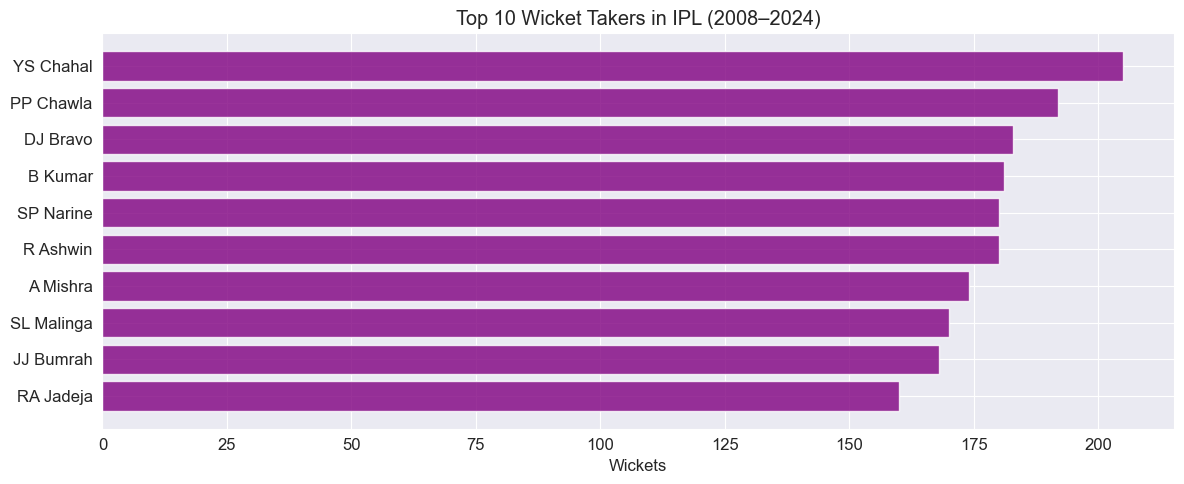

In [122]:
plt.barh(top_bowlers['bowler'][::-1], top_bowlers['wickets'][::-1], color='purple', alpha=0.8)
plt.xlabel('Wickets')
plt.title('Top 10 Wicket Takers in IPL (2008–2024)')
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150)
plt.show()

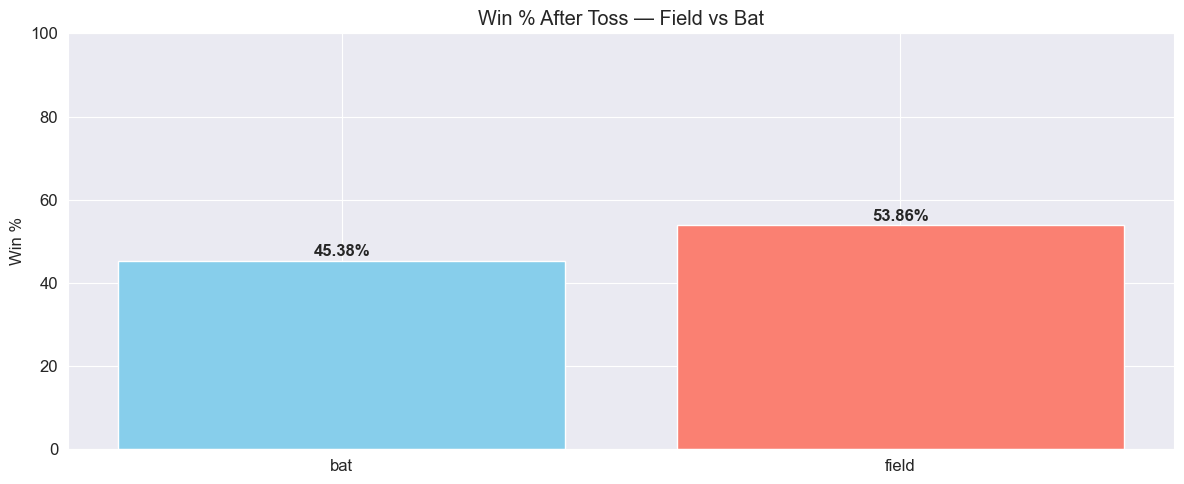

In [120]:
labels = toss_impact['toss_decision']
sizes = toss_impact['win_pct']
plt.bar(labels, sizes, color=['skyblue', 'salmon'])
plt.title('Win % After Toss — Field vs Bat')
plt.ylabel('Win %')
plt.ylim(0, 100)
for i, v in enumerate(sizes):
    plt.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('toss_impact.png', dpi=150)
plt.show()

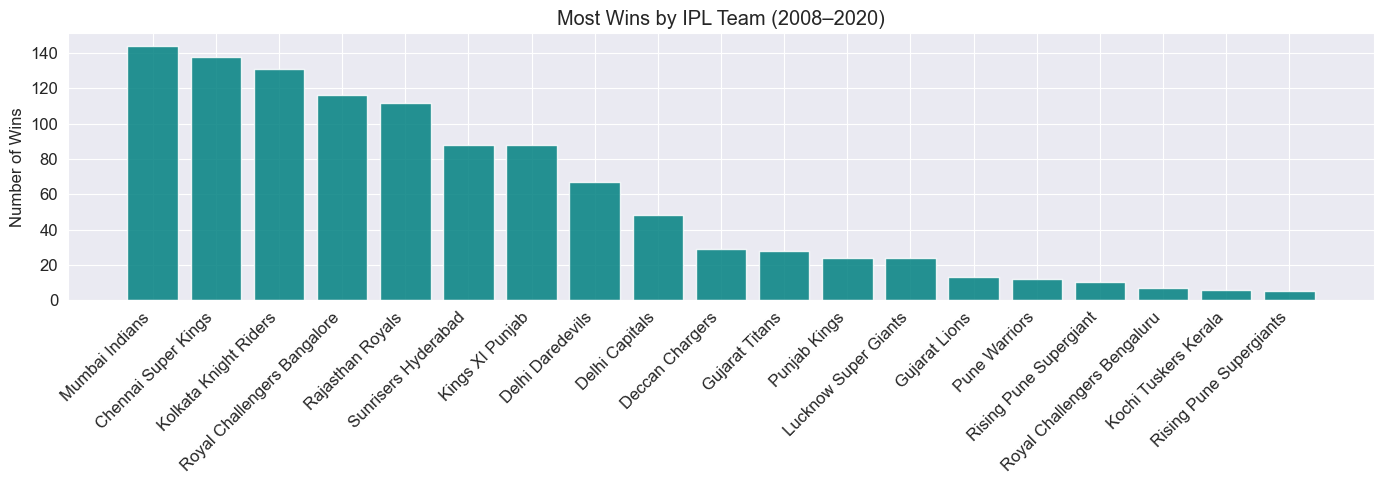

In [124]:
plt.figure(figsize=(14, 5))
plt.bar(team_wins['winner'], team_wins['wins'], color='teal', alpha=0.85)
plt.xticks(rotation=45, ha='right')
plt.title('Most Wins by IPL Team (2008–2020)')
plt.ylabel('Number of Wins')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150)
plt.show()

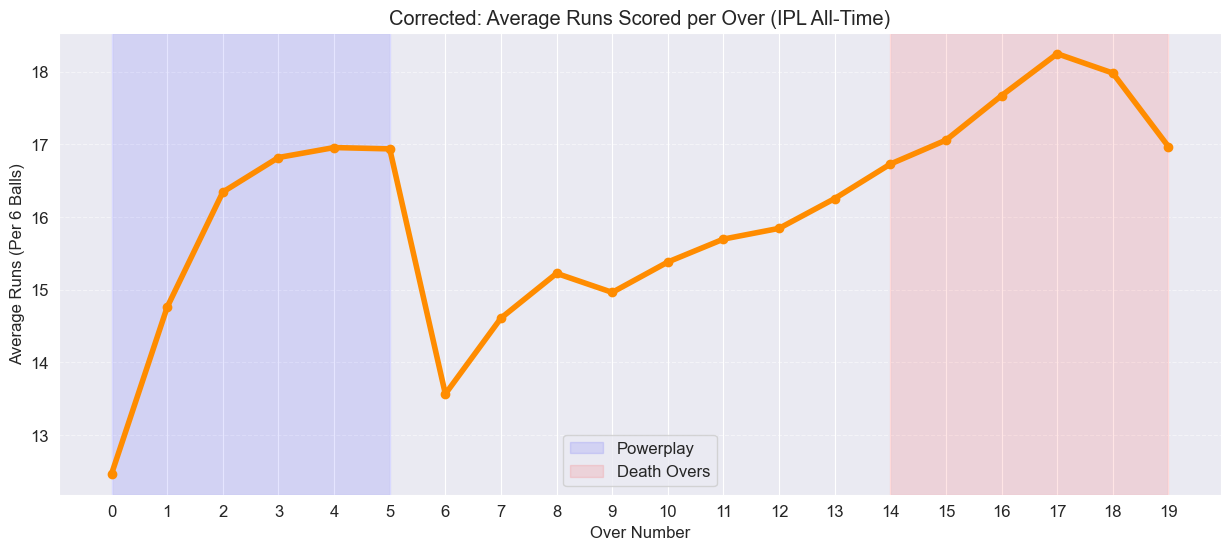

In [134]:
# 1. Sum up runs for every specific over in every specific match
match_over_totals = deliveries.groupby(['match_id', 'over'])['total_runs'].sum().reset_index()

# 2. Now, find the average of those over-totals across all matches
over_runs_avg = match_over_totals.groupby('over')['total_runs'].mean().reset_index()

# 3. Plot this new 'over_runs_avg'
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(over_runs_avg['over'], over_runs_avg['total_runs'], marker='o', color='darkorange', linewidth=4)

# Highlighting phases (0-5 is 1st-6th over)
plt.axvspan(0, 5, alpha=0.1, color='blue', label='Powerplay')
plt.axvspan(14, 19, alpha=0.1, color='red', label='Death Overs')

plt.xticks(range(0, 20))
plt.title('Corrected: Average Runs Scored per Over (IPL All-Time)')
plt.xlabel('Over Number')
plt.ylabel('Average Runs (Per 6 Balls)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

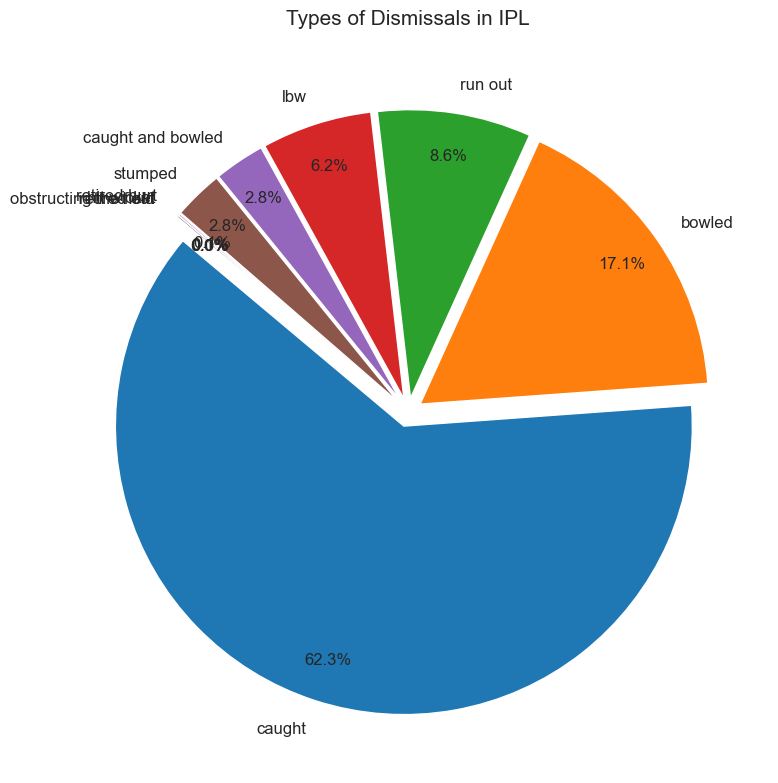

In [150]:
plt.figure(figsize=(10, 8)) # Increase size for more room

# Create an 'explode' list to slightly pull out the slices
# This helps separate the smaller slices from the big ones
explode = [0.05] * len(dismissal_counts) 

plt.pie(dismissal_counts, 
        labels=dismissal_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        explode=explode,          # Pulls slices apart
        pctdistance=0.85,         # Moves % numbers further out
        labeldistance=1.1)        # Moves names further out

plt.title('Types of Dismissals in IPL', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

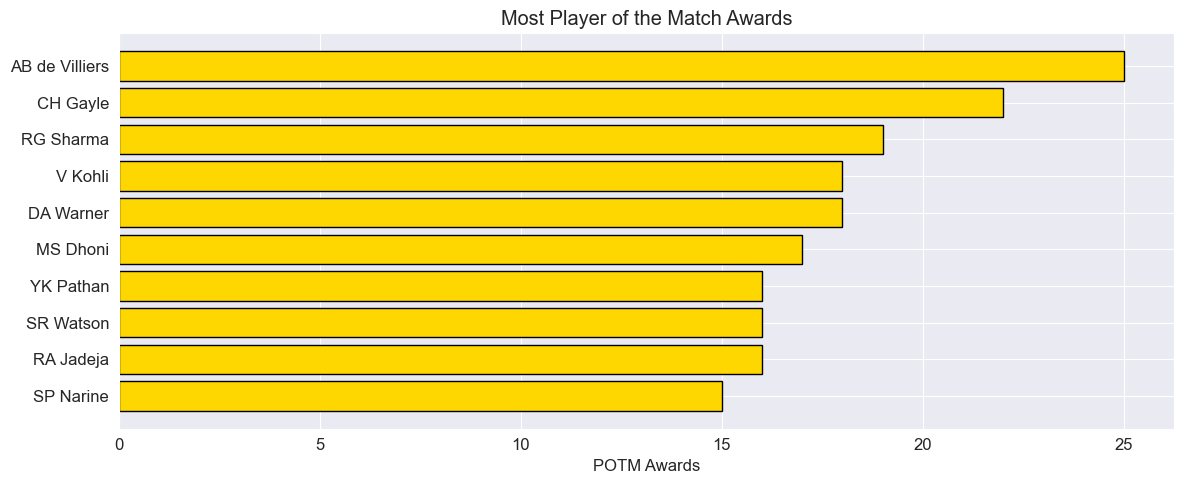

In [152]:
plt.barh(potm['player_of_match'][::-1], potm['awards'][::-1], color='gold', edgecolor='black')
plt.xlabel('POTM Awards')
plt.title('Most Player of the Match Awards')
plt.tight_layout()
plt.savefig('potm.png', dpi=150)
plt.show()

In [154]:
# Save all key tables as CSVs for Tableau
top_batsmen.to_csv('tableau_top_batsmen.csv', index=False)
team_wins.to_csv('tableau_team_wins.csv', index=False)
season_runs.to_csv('tableau_season_runs.csv', index=False)
top_bowlers.to_csv('tableau_top_bowlers.csv', index=False)
toss_impact.to_csv('tableau_toss_impact.csv', index=False)
venue_matches.to_csv('tableau_venues.csv', index=False)
potm.to_csv('tableau_potm.csv', index=False)
kohli_yearly.to_csv('tableau_kohli.csv', index=False)
print("All Tableau CSVs exported.")

All Tableau CSVs exported.
